# Visualização de Focus de Modelos

### Notebook para Carregar e Visualizar, Via Mapas de Calor, o Foco dos Modelos nas Imagens

In [9]:
import torch
import torchvision
from torchvision import transforms

from tensorflow.keras.preprocessing import image

import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tqdm

import cv2
import tensorflow as tf

project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(project_root)

from utils.models_to_pkl import load_model

In [10]:
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(project_root)

dir_imgs_path = "/data/CO2Wounds-V2/processed/train_images_binary/train/leprosy/"

In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [12]:
model_path = os.path.join(project_root, "models", "modelo_binario_do_zero_co2wounds")
model = load_model(model_path)

✅ Modelo carregado de: /home/alyssandro/Documents/Github/leprosy_classification_models-TCC/models/modelo_binario_do_zero_co2wounds.keras


## Esse trecho serve apenas para oos modelos treinados com os pesos do imagenet - (1, 224, 224, 1)

In [13]:
def get_img_array(img_path):
    img = np.load(img_path)

    # Se for 2D, adiciona o canal (fica [H, W, 1])
    if img.ndim == 2:
        img = np.expand_dims(img, axis=-1)

    img = cv2.resize(img, (224, 224))
    img = np.expand_dims(img, axis=0)

    # NÃO use preprocess_input da ResNet se o modelo foi treinado com imagens Y normalizadas
    # Em vez disso, normalize manualmente se necessário:
    img = img.astype(np.float32)
    img /= 255.0  # se seu treinamento usou normalização 0-1
    return img

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Gera o mapa de calor Grad-CAM."""
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradiente da classe com relação aos mapas de ativação
    grads = tape.gradient(class_channel, conv_outputs)

    # Média espacial dos gradientes
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normaliza entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.5, gamma=2.0, percentile=80):

    # Carrega imagem em escala de cinza (canal Y)
    img = np.load(img_path)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Redimensiona heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Normalização baseada em percentil para maior contraste
    max_val = np.percentile(heatmap, percentile)
    heatmap = np.clip(heatmap / (max_val + 1e-8), 0, 1)

    # Aplica gamma para realçar regiões importantes
    heatmap = np.power(heatmap, gamma)

    # Converte para 0-255
    heatmap = np.uint8(255 * heatmap)

    # Colormap JET (azul -> vermelho)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    if img.dtype != np.uint8:
        img = np.clip(img * 255, 0, 255).astype(np.uint8)

    # Sobreposição
    superimposed_img = cv2.addWeighted(heatmap_colored, alpha, img, 1 - alpha, 0)

    # Mostra imagens
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Imagem Original (Y)")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Destacado")
    plt.imshow(superimposed_img)
    plt.axis('off')

    plt.show()

In [ ]:
for img in os.listdir(project_root+dir_imgs_path):
    img_path = project_root + dir_imgs_path + img

    img_array = get_img_array(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out")
    print(img)
    display_gradcam(img_path, heatmap)

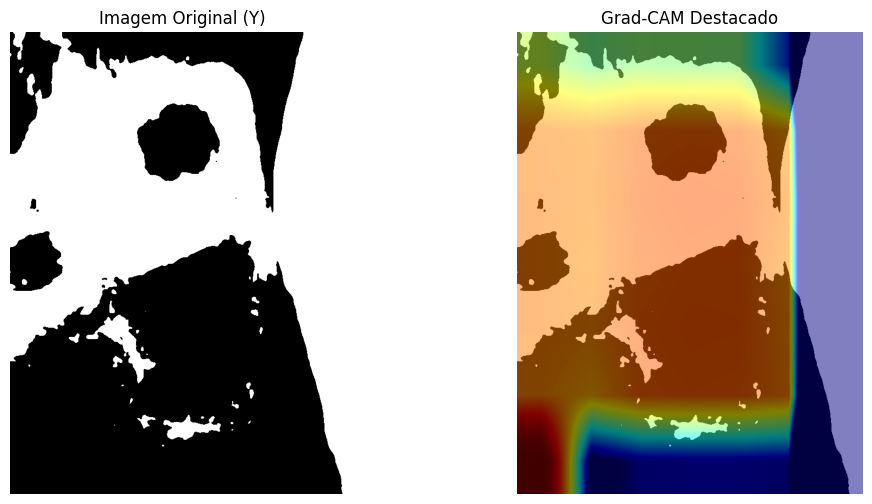

In [20]:
img_path = project_root + dir_imgs_path + "IMG558.npy"

img_array = get_img_array(img_path)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out")
display_gradcam(img_path, heatmap)